In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import glob
from pathlib import Path

# Paths
DATASET_ROOT = Path("../dataset")
POSES_ROOT   = DATASET_ROOT / "poses"
METADATA_DIR = DATASET_ROOT / "metadata"

SIGNS_TARGET = [
    "SOUFFRIR", "AIDER",    "FORT",     "MALADE",   "COEUR",
    "TETE",     "MORT",     "DOS",      "VENTRE",   "FROID",
    "JAMBE",    "JAMBES",   "RESPIRER", "ACCIDENT", "FAIBLE",
    "ENCEINTE", "DIABETE",  "BRAS",     "DOSSIER",  "EFFORT"
]
SIGN_TO_IDX = {s: i for i, s in enumerate(SIGNS_TARGET)}
NUM_CLASSES  = len(SIGNS_TARGET)  # 20

print("Target classes:", NUM_CLASSES)
print("Signs:", SIGNS_TARGET)

Target classes: 20
Signs: ['SOUFFRIR', 'AIDER', 'FORT', 'MALADE', 'COEUR', 'TETE', 'MORT', 'DOS', 'VENTRE', 'FROID', 'JAMBE', 'JAMBES', 'RESPIRER', 'ACCIDENT', 'FAIBLE', 'ENCEINTE', 'DIABETE', 'BRAS', 'DOSSIER', 'EFFORT']


Total instances with poses: 991

Class distribution:
sign
FORT        486
AIDER       170
FROID        47
ENCEINTE     39
SOUFFRIR     38
TETE         36
MORT         36
COEUR        30
MALADE       26
ACCIDENT     20
EFFORT       11
DOS          10
DOSSIER       9
RESPIRER      8
FAIBLE        6
DIABETE       6
BRAS          5
JAMBE         4
VENTRE        3
JAMBES        1


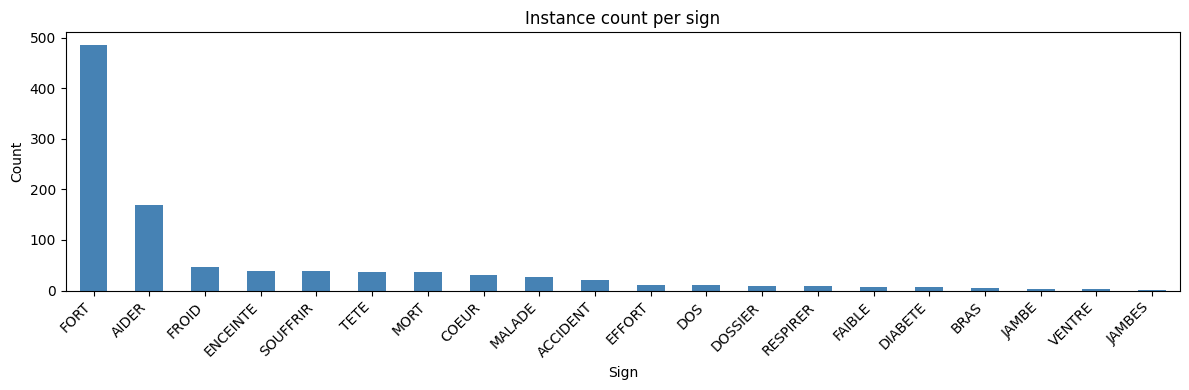

In [2]:
# Load instances that have pose files
instances = pd.read_csv(DATASET_ROOT / "instances.csv")

face_files   = list((POSES_ROOT / "face").glob("*.npy"))
available_ids = {f.stem for f in face_files}

df = instances[instances["id"].isin(available_ids)].copy()
df["label"] = df["sign"].map(SIGN_TO_IDX)
df = df[df["label"].notna()].copy()  # keep only our 20 target signs
df["label"] = df["label"].astype(int)

print(f"Total instances with poses: {len(df)}")
print("\nClass distribution:")
print(df["sign"].value_counts().to_string())

# Plot class distribution
fig, ax = plt.subplots(figsize=(12, 4))
df["sign"].value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Instance count per sign")
ax.set_xlabel("Sign")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Frame length stats:
count    991.000000
mean      22.359233
std       15.982127
min        0.000000
25%       14.000000
50%       19.000000
75%       26.000000
max      243.000000
Name: T, dtype: float64

Instances with T=0: 4


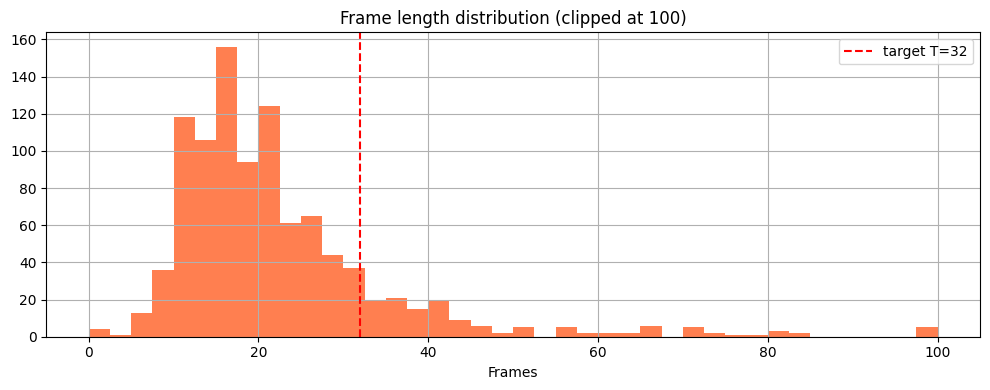

In [3]:
# Load frame lengths for all instances
frame_lengths = {}
for _, row in df.iterrows():
    arr = np.load(POSES_ROOT / "face" / f"{row['id']}.npy")
    frame_lengths[row["id"]] = arr.shape[0]

df["T"] = df["id"].map(frame_lengths)

print("Frame length stats:")
print(df["T"].describe())
print(f"\nInstances with T=0: {(df['T'] == 0).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
df["T"].clip(upper=100).hist(bins=40, ax=ax, color="coral")
ax.axvline(32, color="red", linestyle="--", label="target T=32")
ax.set_title("Frame length distribution (clipped at 100)")
ax.set_xlabel("Frames")
ax.legend()
plt.tight_layout()
plt.show()

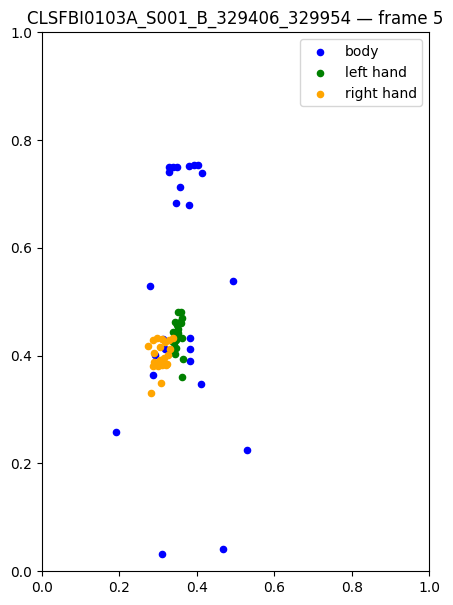

In [4]:
def visualize_skeleton_frame(instance_id, frame_idx=0):
    """Plot body + hands keypoints for a single frame."""
    body  = np.load(POSES_ROOT / "pose"       / f"{instance_id}.npy")  # (T, 33, 3)
    lhand = np.load(POSES_ROOT / "left_hand"  / f"{instance_id}.npy")  # (T, 21, 3)
    rhand = np.load(POSES_ROOT / "right_hand" / f"{instance_id}.npy")  # (T, 21, 3)

    fig, ax = plt.subplots(figsize=(5, 7))
    for kpts, color, label in [
        (body[frame_idx],  "blue",   "body"),
        (lhand[frame_idx], "green",  "left hand"),
        (rhand[frame_idx], "orange", "right hand"),
    ]:
        ax.scatter(kpts[:, 0], 1 - kpts[:, 1], s=20, c=color, label=label)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{instance_id} \u2014 frame {frame_idx}")
    ax.legend()
    plt.show()

# Pick one instance per class
sample_id = df[df["sign"] == "SOUFFRIR"]["id"].iloc[0]
visualize_skeleton_frame(sample_id, frame_idx=5)

In [5]:
# Remove instances with T=0 (no pose data)
bad = df[df["T"] == 0]
print(f"Removing {len(bad)} instances with T=0:")
print(bad[["id", "sign"]].to_string())

df_clean = df[df["T"] > 0].reset_index(drop=True)
print(f"\nInstances after cleaning: {len(df_clean)}")

Removing 4 instances with T=0:
                                     id   sign
7645   CLSFBI0210A_S003_B_548092_548494    DOS
23547  CLSFBI0603A_S014_B_228102_228297   FORT
23551  CLSFBI0603A_S014_B_230221_230425   FORT
23814  CLSFBI0603A_S014_B_443172_443544  AIDER

Instances after cleaning: 987


In [6]:
def resample_sequence(arr: np.ndarray, target_T: int) -> np.ndarray:
    """
    Resample a (T, K, 3) pose array to exactly target_T frames via linear interpolation.
    Works for any T >= 1.
    """
    T = arr.shape[0]
    if T == target_T:
        return arr
    src_idx = np.linspace(0, T - 1, target_T)
    lo = np.floor(src_idx).astype(int).clip(0, T - 1)
    hi = np.ceil(src_idx).astype(int).clip(0, T - 1)
    alpha = (src_idx - lo)[:, None, None]  # (target_T, 1, 1)
    return ((1 - alpha) * arr[lo] + alpha * arr[hi]).astype(arr.dtype)


# Sanity check
dummy = np.random.rand(10, 21, 3).astype(np.float16)
resampled = resample_sequence(dummy, 32)
assert resampled.shape == (32, 21, 3), f"Expected (32,21,3), got {resampled.shape}"
print("resample_sequence OK")

resample_sequence OK


In [7]:
def keypoints_to_heatmap(kpts: np.ndarray, H: int = 64, W: int = 64,
                          sigma: float = 2.0) -> np.ndarray:
    """
    Convert (K, 3) keypoints array (x, y, conf) to a single (H, W) heatmap.
    x and y are assumed to be in [0, 1]. Confidence values < 0 are treated as
    invisible and the keypoint is skipped.

    Returns float32 array of shape (H, W) with values in [0, 1].
    """
    heatmap = np.zeros((H, W), dtype=np.float32)
    for (x, y, c) in kpts:
        if c < 0:  # invisible keypoint
            continue
        px = int(np.clip(x * W, 0, W - 1))
        py = int(np.clip(y * H, 0, H - 1))
        # Place Gaussian blob via meshgrid (vectorised)
        xs = np.arange(W)
        ys = np.arange(H)
        xx, yy = np.meshgrid(xs, ys)
        blob = np.exp(-((xx - px) ** 2 + (yy - py) ** 2) / (2 * sigma ** 2))
        heatmap = np.maximum(heatmap, blob)
    return heatmap


def instance_to_tensor(instance_id: str, target_T: int = 32,
                        H: int = 64, W: int = 64) -> np.ndarray:
    """
    Load the 4 pose arrays for one instance and return a (3, T, H, W) float32 tensor.

    Channels:
      0 - body pose  (33 keypoints)
      1 - left hand  (21 keypoints)
      2 - right hand (21 keypoints)
    Face is omitted (too many landmarks, low relevance for medical signs).
    """
    body  = np.load(POSES_ROOT / "pose"       / f"{instance_id}.npy").astype(np.float32)
    lhand = np.load(POSES_ROOT / "left_hand"  / f"{instance_id}.npy").astype(np.float32)
    rhand = np.load(POSES_ROOT / "right_hand" / f"{instance_id}.npy").astype(np.float32)

    body  = resample_sequence(body,  target_T)   # (T, 33, 3)
    lhand = resample_sequence(lhand, target_T)   # (T, 21, 3)
    rhand = resample_sequence(rhand, target_T)   # (T, 21, 3)

    frames = []
    for t in range(target_T):
        ch_body  = keypoints_to_heatmap(body[t],  H, W)
        ch_lhand = keypoints_to_heatmap(lhand[t], H, W)
        ch_rhand = keypoints_to_heatmap(rhand[t], H, W)
        frames.append(np.stack([ch_body, ch_lhand, ch_rhand], axis=0))  # (3, H, W)

    return np.stack(frames, axis=1)  # (3, T, H, W)


# Sanity check
sample_id = df_clean["id"].iloc[0]
t = instance_to_tensor(sample_id)
assert t.shape == (3, 32, 64, 64), f"Expected (3,32,64,64), got {t.shape}"
assert t.min() >= 0.0 and t.max() <= 1.0, "Values out of [0,1]"
print(f"instance_to_tensor OK: shape={t.shape}, min={t.min():.3f}, max={t.max():.3f}")

instance_to_tensor OK: shape=(3, 32, 64, 64), min=0.000, max=1.000


In [8]:
def augment_temporal_flip(kpts_body, kpts_lhand, kpts_rhand):
    """Reverse the temporal order of the sequence."""
    return kpts_body[::-1], kpts_lhand[::-1], kpts_rhand[::-1]


def augment_horizontal_flip(kpts_body, kpts_lhand, kpts_rhand):
    """
    Flip x-coordinate (mirror left/right). Also swap left and right hand channels.
    Operates on (T, K, 3) arrays.
    """
    def flip_x(arr):
        arr = arr.copy()
        arr[:, :, 0] = 1.0 - arr[:, :, 0]
        return arr
    return flip_x(kpts_body), flip_x(kpts_rhand), flip_x(kpts_lhand)  # swap L/R


def augment_jitter(kpts_body, kpts_lhand, kpts_rhand, std: float = 0.01):
    """Add small Gaussian noise to x,y coordinates."""
    noise = np.random.randn(*kpts_body.shape).astype(np.float32) * std
    noise[:, :, 2] = 0  # do not jitter confidence
    body_j = np.clip(kpts_body + noise, 0.0, 1.0)
    noise = np.random.randn(*kpts_lhand.shape).astype(np.float32) * std
    noise[:, :, 2] = 0
    lhand_j = np.clip(kpts_lhand + noise, 0.0, 1.0)
    noise = np.random.randn(*kpts_rhand.shape).astype(np.float32) * std
    noise[:, :, 2] = 0
    rhand_j = np.clip(kpts_rhand + noise, 0.0, 1.0)
    return body_j, lhand_j, rhand_j


def augment_temporal_crop(kpts_body, kpts_lhand, kpts_rhand, target_T: int = 32):
    """
    Randomly crop a sub-sequence of target_T frames from a longer sequence.
    If T <= target_T, the sequence is left unchanged (resampling handles padding).
    """
    T = kpts_body.shape[0]
    if T <= target_T:
        return kpts_body, kpts_lhand, kpts_rhand
    start = np.random.randint(0, T - target_T)
    return (kpts_body[start:start+target_T],
            kpts_lhand[start:start+target_T],
            kpts_rhand[start:start+target_T])


print("Augmentation functions defined.")

Augmentation functions defined.


In [9]:
from tqdm.notebook import tqdm

TARGET_T = 32
H, W     = 64, 64

# Load the official train/test split
with open(METADATA_DIR / "splits" / "train.json") as f:
    train_ids = set(json.load(f))
with open(METADATA_DIR / "splits" / "test.json") as f:
    test_ids = set(json.load(f))

df_train = df_clean[df_clean["id"].isin(train_ids)].reset_index(drop=True)
df_test  = df_clean[df_clean["id"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(df_train)} instances | Test: {len(df_test)} instances")
print("\nTrain class distribution:")
print(df_train["sign"].value_counts().to_string())

Train: 607 instances | Test: 380 instances

Train class distribution:
sign
FORT        279
AIDER       116
FROID        25
ENCEINTE     25
MORT         24
TETE         22
SOUFFRIR     21
COEUR        21
MALADE       17
ACCIDENT     16
DOS           7
DOSSIER       7
FAIBLE        6
RESPIRER      5
DIABETE       5
BRAS          4
EFFORT        4
JAMBE         2
VENTRE        1


In [10]:
def load_raw_poses(instance_id: str):
    """Return (body, lhand, rhand) as float32 (T, K, 3) arrays."""
    body  = np.load(POSES_ROOT / "pose"       / f"{instance_id}.npy").astype(np.float32)
    lhand = np.load(POSES_ROOT / "left_hand"  / f"{instance_id}.npy").astype(np.float32)
    rhand = np.load(POSES_ROOT / "right_hand" / f"{instance_id}.npy").astype(np.float32)
    return body, lhand, rhand


def poses_to_tensor(body, lhand, rhand, target_T=32, H=64, W=64) -> np.ndarray:
    """Convert resampled (T, K, 3) arrays to (3, T, H, W) heatmap tensor."""
    body  = resample_sequence(body,  target_T)
    lhand = resample_sequence(lhand, target_T)
    rhand = resample_sequence(rhand, target_T)
    frames = []
    for t in range(target_T):
        frames.append(np.stack([
            keypoints_to_heatmap(body[t],  H, W),
            keypoints_to_heatmap(lhand[t], H, W),
            keypoints_to_heatmap(rhand[t], H, W),
        ], axis=0))
    return np.stack(frames, axis=1)  # (3, T, H, W)


# Build training set with augmentation (original + 3 augmented copies)
X_train, y_train = [], []

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Building train"):
    body, lhand, rhand = load_raw_poses(row["id"])

    # Original
    X_train.append(poses_to_tensor(body, lhand, rhand, TARGET_T, H, W))
    y_train.append(row["label"])

    # Augmentation 1: horizontal flip
    b_f, l_f, r_f = augment_horizontal_flip(body, lhand, rhand)
    X_train.append(poses_to_tensor(b_f, l_f, r_f, TARGET_T, H, W))
    y_train.append(row["label"])

    # Augmentation 2: temporal flip
    b_t, l_t, r_t = augment_temporal_flip(body, lhand, rhand)
    X_train.append(poses_to_tensor(b_t, l_t, r_t, TARGET_T, H, W))
    y_train.append(row["label"])

    # Augmentation 3: spatial jitter
    b_j, l_j, r_j = augment_jitter(body, lhand, rhand, std=0.01)
    X_train.append(poses_to_tensor(b_j, l_j, r_j, TARGET_T, H, W))
    y_train.append(row["label"])

X_train = np.stack(X_train).astype(np.float32)  # (N*4, 3, T, H, W)
y_train = np.array(y_train, dtype=np.int64)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}, unique labels: {np.unique(y_train)}")

Building train:   0%|          | 0/607 [00:00<?, ?it/s]

X_train shape: (2428, 3, 32, 64, 64)
y_train shape: (2428,), unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19]


In [11]:
X_test, y_test = [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Building test"):
    body, lhand, rhand = load_raw_poses(row["id"])
    X_test.append(poses_to_tensor(body, lhand, rhand, TARGET_T, H, W))
    y_test.append(row["label"])

X_test = np.stack(X_test).astype(np.float32)   # (N_test, 3, T, H, W)
y_test = np.array(y_test, dtype=np.int64)
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Building test:   0%|          | 0/380 [00:00<?, ?it/s]

X_test shape:  (380, 3, 32, 64, 64)
y_test shape:  (380,)


In [ ]:
import os

save_dir = Path("../dataset/preprocessed")
save_dir.mkdir(parents=True, exist_ok=True)

np.save(save_dir / "X_train.npy", X_train)
np.save(save_dir / "y_train.npy", y_train)
np.save(save_dir / "X_test.npy",  X_test)
np.save(save_dir / "y_test.npy",  y_test)

# Also save the label map for reference
import json
with open(save_dir / "sign_to_idx.json", "w") as f:
    json.dump(SIGN_TO_IDX, f, indent=2)

print("Saved preprocessed data:")
print(f"  X_train: {X_train.shape}  ({X_train.nbytes / 1e6:.1f} MB)")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}  ({X_test.nbytes / 1e6:.1f} MB)")
print(f"  y_test:  {y_test.shape}")
print(f"  sign_to_idx.json")

Saved preprocessed data:
  X_train: (2428, 3, 32, 64, 64)  (3818.9 MB)
  y_train: (2428,)
  X_test:  (380, 3, 32, 64, 64)  (597.7 MB)
  y_test:  (380,)
  sign_to_idx.json
